<a href="https://colab.research.google.com/github/SASU004/AI-ML/blob/main/cats_vs_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [10]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:04<00:00, 192MB/s]



In [11]:
import zipfile
zip_ref=zipfile.ZipFile('dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [12]:
zip_ref = zipfile.ZipFile('train.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [13]:
zip_ref = zipfile.ZipFile('test1.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [24]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [30]:
#now we need to feed all the images from train folder
#can do using custom os module
#but huge dataset = more ram consumption
#so we use generator

#generators
#divide data in batches
#so a single batch is loaded in ram
#when work is done it ggoes away and loads a new batch

#one egenrator for training another for validation

train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/test1',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

#unfortunately the dataset is shit XD

Found 25000 files belonging to 2 classes.
Found 0 files belonging to 2 classes.


ValueError: No images found in directory /content/test1. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')

In [15]:
import os
import shutil

# Create subdirectories for classes
os.makedirs('/content/train/cat', exist_ok=True)
os.makedirs('/content/train/dog', exist_ok=True)

# Move images into respective folders based on filename
path = '/content/train/'
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

for f in files:
    if f.startswith('cat'):
        shutil.move(os.path.join(path, f), os.path.join(path, 'cat', f))
    elif f.startswith('dog'):
        shutil.move(os.path.join(path, f), os.path.join(path, 'dog', f))

print('Reorganization complete.')

Reorganization complete.


In [16]:
# Now we create the generators using a validation split
# This replaces the need for the unlabeled test1 folder for validation

train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="training",
    seed=1337
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="validation",
    seed=1337
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [17]:
#normalization
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

  train_ds=train_ds.map(process)
  validation_ds=validation_ds.map(process)
#map takes images from the datasets

In [25]:
#CNN MODEL
model= Sequential()
# filter== kernel
# here no of kernels = 32
# size of kernel is 3x3

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
#pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
#pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
#pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#classification so binary cross entropy


In [28]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.5767 - loss: 1.5123 - val_accuracy: 0.6422 - val_loss: 0.6205
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.6705 - loss: 0.6005 - val_accuracy: 0.7076 - val_loss: 0.5406
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7446 - loss: 0.5109 - val_accuracy: 0.7726 - val_loss: 0.4833
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7757 - loss: 0.4627 - val_accuracy: 0.7638 - val_loss: 0.4865
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.8112 - loss: 0.3996 - val_accuracy: 0.7932 - val_loss: 0.4529
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.8442 - loss: 0.3377 - val_accuracy: 0.7844 - val_loss: 0.4805
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 90ms/step - accuracy: 0.8712 - loss: 0.2873 - val_accuracy: 0.7866 - val_loss: 0.5108
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.9000 - loss: 0.2303 - 

<function matplotlib.pyplot.show(close=None, block=None)>

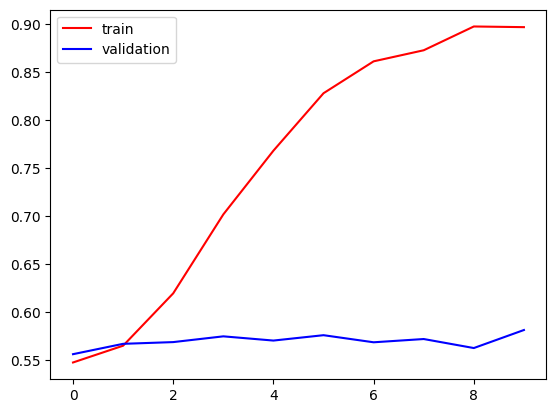

In [22]:
#first
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()


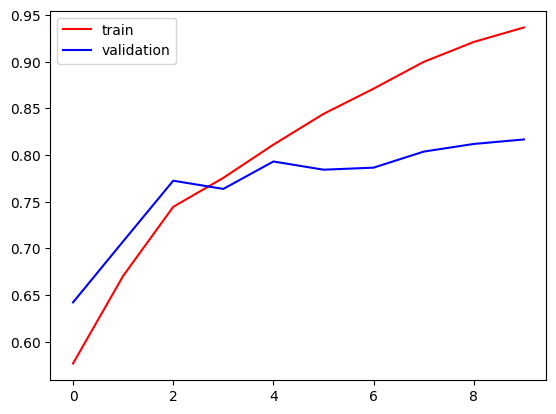

In [33]:
#2nd
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

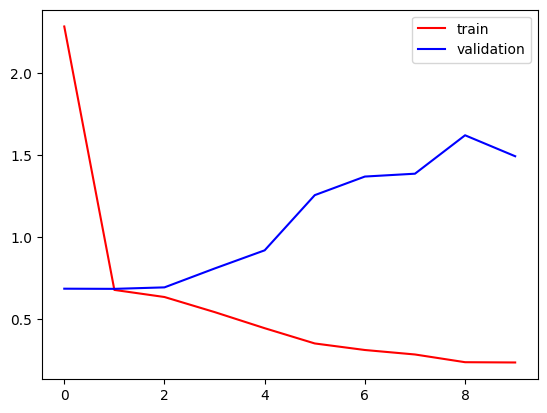

In [23]:
#first
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()


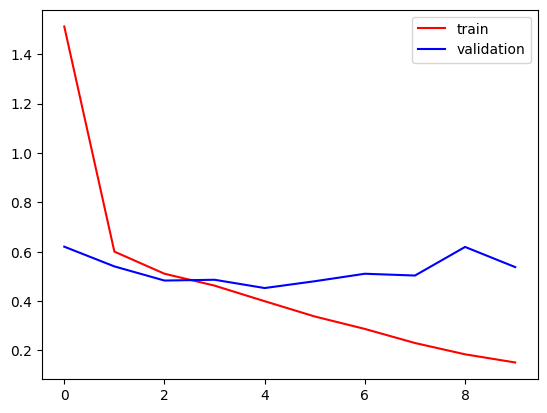

In [34]:
#2nd
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()


In [29]:
#ways to reduce overfitting
#add more data which is not possible
#data augmentation
#l1 l2
#reduce complexity
#dropout
#batch normalization



In [35]:
import cv2

In [43]:
test_img=cv2.imread('/content/dog.jpg')

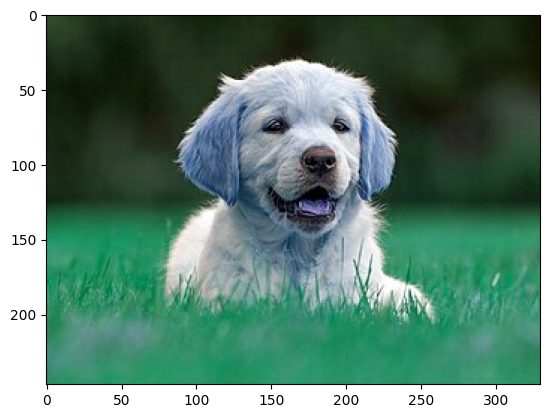

In [44]:
plt.imshow(test_img)

In [45]:
test_img.shape

(247, 330, 3)

In [46]:
test_img=cv2.resize(test_img,(256,256))

In [47]:
test_input=test_img.reshape((1,256,256,3))
#mean 1 image with 256 256 3 dimentions

In [48]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.9999933]], dtype=float32)